
# RBC Polymerization — Matching-Timepoint MAE (No Interpolation)

This notebook:
1. Reads `kinetics-seven_Jianlu.xlsx` with subtype counts in headers.
2. Computes the **weighted overall polymerized fraction** per timepoint for each sheet.
3. Reads your **model curve** from `state_ratio_plot_binary.csv`.
4. Computes **MAE using only timepoints that appear in the measured data** (exact matches only, no interpolation).
5. Saves aligned CSVs and prints a summary.


In [27]:

# --- Configuration ---
DATA_XLSX = "../kinetics-seven_Jianlu.xlsx"          # measured workbook
MODEL_CURVE_CSV = "../state_ratio_plot_binary.csv"   # your other curve (coarser resolution)
SHEETS_TO_PROCESS = None  # e.g., ['MGH2133']; None -> all sheets


In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [29]:

def detect_columns(df, time_candidates=('time','t','timepoint'), value_candidates=('value','y','fraction','polymerized_fraction')):
    cols = [c.strip() if isinstance(c, str) else c for c in df.columns]
    df = df.copy()
    df.columns = cols
    def first(cands, cols):
        for c in cands:
            if c in cols:
                return c
        return None
    tcol = first(time_candidates, df.columns) or df.columns[0]
    vcol = first(value_candidates, df.columns) or df.columns[1]
    return tcol, vcol

def weighted_overall_fraction(df, time_col='cells'):
    # Choose time column
    if time_col not in df.columns:
        time_col = df.columns[0]
    subtype_cols = [c for c in df.columns if c != time_col]
    counts = []
    cols_parsed = []
    for c in subtype_cols:
        try:
            counts.append(int(c) if not isinstance(c, (int, float, np.integer)) else int(c))
            cols_parsed.append(c)
        except Exception:
            pass
    if not cols_parsed:
        raise ValueError("No numeric subtype headers found; ensure subtype columns are named with counts.")
    counts_arr = np.array(counts, dtype=float)
    frac_df = df[cols_parsed].apply(pd.to_numeric, errors='coerce')
    valid_mask = ~frac_df.isna().all(axis=1)
    frac_df = frac_df[valid_mask].reset_index(drop=True)
    time_series = df.loc[valid_mask, time_col].reset_index(drop=True)
    counts_broadcast = np.tile(counts_arr, (frac_df.shape[0], 1))
    numer = np.nansum(frac_df.to_numpy() * counts_broadcast, axis=1)
    denom = np.nansum((~frac_df.isna()).to_numpy() * counts_broadcast, axis=1)
    weighted = np.where(denom > 0, numer/denom, np.nan)
    res = pd.DataFrame({"timepoint": pd.to_numeric(time_series, errors='coerce'), "polymerized_fraction_all": weighted})
    res = res.dropna(subset=["timepoint"])
    return res

def mae_on_matching_times(ref_df, model_df, time_round=None):
    """
    Join on exact matching timepoints (optionally after rounding). No interpolation.
    Returns MAE and merged DataFrame with columns: timepoint, measured_fraction, model_fraction, abs_error
    """
    ref = ref_df.copy()
    model = model_df.copy()
    # Standardize column names
    ref = ref.rename(columns={"polymerized_fraction_all":"measured_fraction"})
    model.columns = ["time","value"]
    # Numeric
    ref["timepoint"] = pd.to_numeric(ref["timepoint"], errors='coerce')
    ref["measured_fraction"] = pd.to_numeric(ref["measured_fraction"], errors='coerce')
    model["time"] = pd.to_numeric(model["time"], errors='coerce')
    model["value"] = pd.to_numeric(model["value"], errors='coerce')
    ref = ref.dropna(subset=["timepoint","measured_fraction"])
    model = model.dropna(subset=["time","value"])
    # Optional rounding (helps if times are floats that should match at a given precision)
    if time_round is not None:
        ref["timepoint_key"] = ref["timepoint"].round(time_round)
        model["time_key"] = model["time"].round(time_round)
        merged = ref.merge(model, left_on="timepoint_key", right_on="time_key", how="inner")
    else:
        merged = ref.merge(model, left_on="timepoint", right_on="time", how="inner")
    merged = merged.sort_values("timepoint")
    merged["abs_error"] = (merged["measured_fraction"] - merged["value"]).abs()
    mae = merged["abs_error"].mean() if len(merged) else np.nan
    return mae, merged[["timepoint","measured_fraction","value","abs_error"]]


[Saved] MGH2133_polymerized_fraction_all.csv  (24 rows)
MGH2133: matches=23, MAE (exact times) = 1.884192
[Saved] MGH2133_aligned_matching_times.csv


/var/folders/08/4mg4trr52cz6gmp1vkmspz080000gn/T/ipykernel_35682/191578984.py:65: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged = ref.merge(model, left_on="timepoint", right_on="time", how="inner")


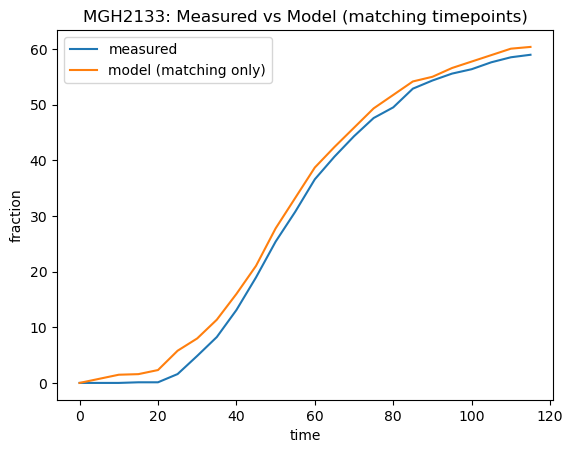

[MGH2134] Skipped: index 0 is out of bounds for axis 0 with size 0


In [18]:

# --- Main: compute measured overall curve(s) and MAE on matching timepoints ---
xlsx = pd.ExcelFile(DATA_XLSX)
sheet_names = SHEETS_TO_PROCESS or xlsx.sheet_names

# Read model curve
model_raw = pd.read_csv(MODEL_CURVE_CSV)
tcol, vcol = detect_columns(model_raw)
model_curve = model_raw[[tcol, vcol]].copy()
model_curve.columns = ["time", "value"]

for sheet in sheet_names:
    df = pd.read_excel(xlsx, sheet_name=sheet)
    df.columns = [c if not isinstance(c, str) else c.strip() for c in df.columns]
    try:
        measured = weighted_overall_fraction(df, time_col='cells')
    except Exception as e:
        print(f"[{sheet}] Skipped: {e}")
        continue
    # Save measured CSV
    out_csv = f"{sheet}_polymerized_fraction_all.csv"
    measured.to_csv(out_csv, index=False)
    print(f"[Saved] {out_csv}  ({len(measured)} rows)")
    # MAE with exact matches (no interpolation)
    mae, aligned = mae_on_matching_times(measured, model_curve, time_round=None)
    n_match = len(aligned)
    print(f"{sheet}: matches={n_match}, MAE (exact times) = {mae if pd.notna(mae) else float('nan'):.6f}")
    aligned_out = f"{sheet}_aligned_matching_times.csv"
    aligned.to_csv(aligned_out, index=False)
    print(f"[Saved] {aligned_out}")
    # Plot measured vs model only at matching times
    if n_match:
        plt.figure()
        plt.plot(aligned["timepoint"], aligned["measured_fraction"], label="measured")
        plt.plot(aligned["timepoint"], aligned["value"], label="model (matching only)")
        plt.title(f"{sheet}: Measured vs Model (matching timepoints)")
        plt.xlabel("time")
        plt.ylabel("fraction")
        plt.legend()
        plt.show()


Extracted subtype 'D' timeline from Excel:
   timepoint  subtype_percent
0          0         0.000000
1         10         0.000000
2         15         0.000000
3         20         0.000000
4         25         8.333333
Number of Excel timepoints: 24

Loaded CSV and per-frame curve for 'Class_3':
   time  value
0   0.0    0.0
1   0.5    0.0
2   1.0    0.0
3   1.5    0.0
4   2.0    0.0
Number of per-frame CSV rows: 240

[ORIGINAL ROUNDED] Subtype 'D' vs Class_3:
  rows in aligned_rounded (can be > #Excel timepoints): 47
  MAE_rounded = 6.044 percentage points

[EXACT TIME] Subtype 'D' vs Class_3:
  rows in aligned_exact (should be ≤ #Excel timepoints): 23
  MAE_exact   = 6.061 percentage points

Unique Excel timepoints in aligned_exact: [  0  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115]


/var/folders/08/4mg4trr52cz6gmp1vkmspz080000gn/T/ipykernel_35682/2277868879.py:141: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  aligned_exact = ref2.merge(csv2, left_on="timepoint", right_on="time", how="inner")


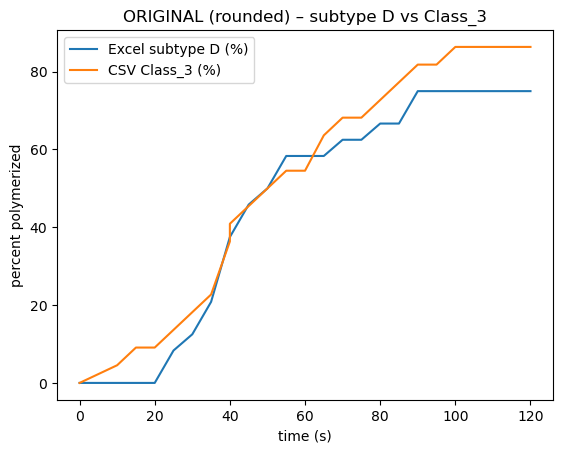

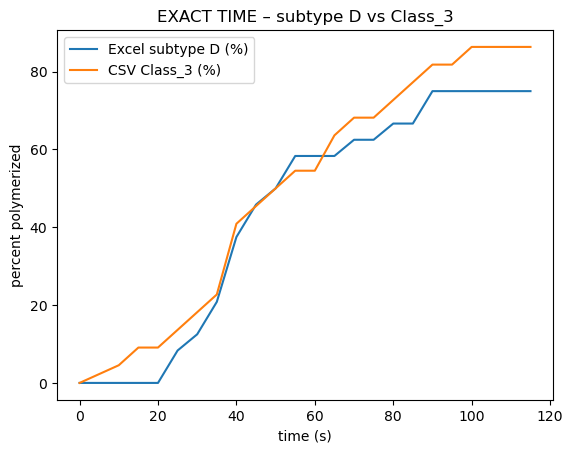

In [73]:
# === Compare one subtype from Excel vs one class from CSV ===
# This cell computes TWO MAEs:
#   1) MAE_rounded: old method (rounding-based merge, can double-count times)
#   2) MAE_exact:   new method (exact time equality, no mean/max over frames)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
SUBTYPE_LETTER   = "D"          # e.g. "A", "B", "C", "D", "G", ...
MODEL_COL        = "Class_3"    # e.g. "Class_3", "Class_6", ...

DATA_XLSX        = "../kinetics-seven_Jianlu.xlsx"
SHEET            = "MGH2133"

MODEL_CSV        = "..//state_ratio_report.csv"
FRAME_COL        = "FrameIndex"   # each index is one frame
FRAME_PERIOD_SEC = 0.5            # seconds per frameIndex step

TIME_UNIT        = "seconds"      # "seconds" or "minutes"
TIME_ROUND_ORIG  = 0              # for the old rounded method (bad one)
# -----------------------------


# === 1) Extract subtype SUBTYPE_LETTER from Excel into measured_df ===
df_raw = pd.read_excel(DATA_XLSX, sheet_name=SHEET, header=None)

# Layout:
#   row 0: header names   ('cells', 369, 323, ...)
#   row 1: subtype labels ('A','B','C','D',...)
#   row 2+: numeric data
header_row = df_raw.iloc[0]
label_row  = df_raw.iloc[1]
data_rows  = df_raw.iloc[2:].reset_index(drop=True)

# Use row 0 as column names
data_rows.columns = header_row

# Time column is the first header (usually 'cells')
time_col = header_row.iloc[0]
time_series = pd.to_numeric(data_rows[time_col], errors="coerce")

# Find columns corresponding to the chosen subtype letter
sub_indices = [i for i, v in enumerate(label_row)
               if str(v).strip().upper() == SUBTYPE_LETTER.upper()]
if not sub_indices:
    raise ValueError(f"Subtype '{SUBTYPE_LETTER}' not found in row 2 of sheet '{SHEET}'.")

# Collect all subtype columns (average them if multiple)
sub_values = []
for idx in sub_indices:
    colname = header_row[idx]
    vals = pd.to_numeric(data_rows[colname], errors="coerce")
    sub_values.append(vals)

sub_fraction = pd.concat(sub_values, axis=1).mean(axis=1)

# If Excel values look like fractions [0,1], convert to percent [0,100]
if sub_fraction.dropna().quantile(0.95) <= 1.5:
    sub_fraction = sub_fraction * 100.0

measured_df = pd.DataFrame({
    "timepoint": time_series,
    "subtype_percent": sub_fraction
}).dropna(subset=["timepoint"])

measured_df = measured_df.sort_values("timepoint").reset_index(drop=True)

print(f"Extracted subtype '{SUBTYPE_LETTER}' timeline from Excel:")
print(measured_df.head())
print("Number of Excel timepoints:", measured_df["timepoint"].nunique())


# === 2) Load CSV and compute time from FrameIndex ===
csv = pd.read_csv(MODEL_CSV)

if MODEL_COL not in csv.columns:
    raise ValueError(f"Column '{MODEL_COL}' not found in CSV. Available: {list(csv.columns)}")
if FRAME_COL not in csv.columns:
    raise ValueError(f"Frame column '{FRAME_COL}' not found in CSV. Available: {list(csv.columns)}")

csv["frame"] = pd.to_numeric(csv[FRAME_COL], errors="coerce")
csv["value"] = pd.to_numeric(csv[MODEL_COL],  errors="coerce")

# Convert frame index to time
time_sec = csv["frame"] * FRAME_PERIOD_SEC
if TIME_UNIT == "minutes":
    csv["time"] = time_sec / 60.0
else:
    csv["time"] = time_sec  # seconds

csv = csv.dropna(subset=["time", "value"])

# If CSV values look like fractions [0,1], convert to percent
q95 = np.nanpercentile(csv["value"].to_numpy(dtype=float), 95)
if q95 <= 1.5:
    csv["value"] = csv["value"] * 100.0

# Clean per-frame curve
csv_clean = csv[["time", "value"]].sort_values("time").reset_index(drop=True)

print(f"\nLoaded CSV and per-frame curve for '{MODEL_COL}':")
print(csv_clean.head())
print("Number of per-frame CSV rows:", len(csv_clean))


# === 3) ORIGINAL METHOD (ROUNDED MERGE) – can double-count timepoints ===
ref1 = measured_df.copy()
ref1["timepoint"] = pd.to_numeric(ref1["timepoint"], errors="coerce")
ref1 = ref1.dropna(subset=["timepoint", "subtype_percent"]).sort_values("timepoint")

csv1 = csv_clean.copy()

ref1["time_key"] = ref1["timepoint"].round(TIME_ROUND_ORIG)
csv1["time_key"] = csv1["time"].round(TIME_ROUND_ORIG)

aligned_rounded = ref1.merge(csv1, on="time_key", how="inner")
aligned_rounded = aligned_rounded.sort_values("timepoint")
aligned_rounded["abs_error_pp"] = (aligned_rounded["subtype_percent"] - aligned_rounded["value"]).abs()

mae_rounded = aligned_rounded["abs_error_pp"].mean() if len(aligned_rounded) else np.nan
matches_rounded = len(aligned_rounded)

print(f"\n[ORIGINAL ROUNDED] Subtype '{SUBTYPE_LETTER}' vs {MODEL_COL}:")
print("  rows in aligned_rounded (can be > #Excel timepoints):", matches_rounded)
print("  MAE_rounded = {:.3f} percentage points".format(mae_rounded))


# === 4) EXACT-TIME METHOD (what you want) ===
# Exact match: Excel timepoint == CSV time, no rounding, no grouping

ref2 = measured_df.copy()
ref2["timepoint"] = pd.to_numeric(ref2["timepoint"], errors="coerce")
ref2 = ref2.dropna(subset=["timepoint", "subtype_percent"]).sort_values("timepoint")

csv2 = csv_clean.copy()
csv2["time"] = pd.to_numeric(csv2["time"], errors="coerce")
csv2 = csv2.dropna(subset=["time"])

aligned_exact = ref2.merge(csv2, left_on="timepoint", right_on="time", how="inner")
aligned_exact = aligned_exact.sort_values("timepoint")
aligned_exact["abs_error_pp"] = (aligned_exact["subtype_percent"] - aligned_exact["value"]).abs()

mae_exact = aligned_exact["abs_error_pp"].mean() if len(aligned_exact) else np.nan
matches_exact = len(aligned_exact)

print(f"\n[EXACT TIME] Subtype '{SUBTYPE_LETTER}' vs {MODEL_COL}:")
print("  rows in aligned_exact (should be ≤ #Excel timepoints):", matches_exact)
print("  MAE_exact   = {:.3f} percentage points".format(mae_exact))

print("\nUnique Excel timepoints in aligned_exact:", aligned_exact["timepoint"].unique())


# === 5) Plot both methods ===
if matches_rounded:
    plt.figure()
    plt.plot(aligned_rounded["timepoint"], aligned_rounded["subtype_percent"],
             label=f"Excel subtype {SUBTYPE_LETTER} (%)")
    plt.plot(aligned_rounded["timepoint"], aligned_rounded["value"],
             label=f"CSV {MODEL_COL} (%)")
    plt.title(f"ORIGINAL (rounded) – subtype {SUBTYPE_LETTER} vs {MODEL_COL}")
    plt.xlabel(f"time ({'s' if TIME_UNIT == 'seconds' else 'min'})")
    plt.ylabel("percent polymerized")
    plt.legend()
    plt.show()

if matches_exact:
    plt.figure()
    plt.plot(aligned_exact["timepoint"], aligned_exact["subtype_percent"],
             label=f"Excel subtype {SUBTYPE_LETTER} (%)")
    plt.plot(aligned_exact["timepoint"], aligned_exact["value"],
             label=f"CSV {MODEL_COL} (%)")
    plt.title(f"EXACT TIME – subtype {SUBTYPE_LETTER} vs {MODEL_COL}")
    plt.xlabel(f"time ({'s' if TIME_UNIT == 'seconds' else 'min'})")
    plt.ylabel("percent polymerized")
    plt.legend()
    plt.show()




